In [7]:
import sys
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

import ee
ee.Initialize(project='mapbiomas-india')

# Add parent directory to path to import the module
sys.path.append('..')
from feature_selection.feature_selection_module import EEFeatureSelectionModule

# Embed standardized logging for transparent workflow tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [8]:
# Load dataset metadata
classwise_samples_scaled_2k_10k = pd.read_csv('data/classwise_samples_scaled_2k_10k.csv')
runs_analysis_df = pd.read_csv('data/groupwise_runs_default_and_scaled_samples.csv')
region_numbers_df = pd.read_csv('data/regions_area.csv')
legends_df = pd.read_csv('data/class_legend.csv')

# Identify the top-performing region from previous analysis
test_region = runs_analysis_df.sort_values(by=['f1_weighted'], ascending=False).iloc[0]
region_code = test_region['region']
region_id = int(region_numbers_df[region_numbers_df['region_code'] == region_code]['region_id'].iloc[0])
sample_version_in = int(test_region['sample_version'])
n_trees = int(test_region['n_trees'])

# Prepare class balancing sample dictionary
balance_samples = list(map(list, dict(zip(
    classwise_samples_scaled_2k_10k['l2_code'],
    classwise_samples_scaled_2k_10k[region_code]
)).items()))

print(f"Selected Region: {region_code} (ID: {region_id})")
print(f"Sample Version: v{sample_version_in} | Random Forest Trees: {n_trees}")

Selected Region: DES (ID: 3)
Sample Version: v7 | Random Forest Trees: 50


In [36]:
sum([y for [x,y] in balance_samples])

7625

In [15]:
# Regional and Temporal Parameters
YEARS = [1995, 2005, 2015, 2024]
# YEARS = [2015]

def drop_collinear_features(df, threshold=0.85):
    """Identifies and drops highly correlated features using Spearman rank correlation."""
    corr_matrix = df.corr(method='spearman').abs()
    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return to_drop

In [17]:
stable_features_per_year = {}
feature_ranks_per_year = {}

for yr in YEARS:
    logging.info(f"====== PROCESSING TEMPORAL SNAPSHOT: {yr} ======")
    
    # 1. Initialize Module & Balance Data
    selector = EEFeatureSelectionModule(
        region_id=region_id, 
        year=yr, 
        sample_version_in=sample_version_in, 
        number_of_trees=n_trees
    )
    _ = selector.load_and_balance_data(balance_samples=balance_samples)
    
    # 2. Localize Training Data for Scikit-Learn
    # Exclude non-predictive metadata properties
    drop_props = ee.List(['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion'])
    all_bands = ee.List(selector.training_partition.first().propertyNames()).removeAll(drop_props).getInfo()
    
    logging.info(f"Downloading training partition for {len(all_bands)} bands...")
    try:
        url = selector.training_partition.getDownloadURL(filetype='csv', selectors=all_bands + ['class'])
        df = pd.read_csv(url)
    except Exception as e:
        logging.warning(f"Direct download failed: {e}. Falling back to 5000-sample limit.")
        sampled = selector.training_partition.select(all_bands + ['class']).limit(5000).getInfo()
        df = pd.DataFrame([feat['properties'] for feat in sampled['features']])
        
    X = df.drop(columns=['class', 'system:index'], errors='ignore')
    y = df['class']
    
    # 3. Filter Method: Remove Multicollinearity
    collinear_to_drop = drop_collinear_features(X, threshold=0.85)
    X_filtered = X.drop(columns=collinear_to_drop)
    logging.info(f"Dropped {len(collinear_to_drop)} highly correlated features. {X_filtered.shape[1]} remain.")
    
    # 4. Embedded Method: RFECV
    rf = RandomForestClassifier(n_estimators=n_trees,min_samples_leaf = 5, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    logging.info("Running Recursive Feature Elimination with Cross-Validation...")
    rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_weighted', n_jobs=-1)
    rfecv.fit(X_filtered, y)
    
    # 5. Extract Results
    selected_features = X_filtered.columns[rfecv.support_].tolist()
    stable_features_per_year[yr] = selected_features
    
    ranks = pd.DataFrame({'band': X_filtered.columns, f'rank_{yr}': rfecv.ranking_})
    feature_ranks_per_year[yr] = ranks
    
    logging.info(f"Optimal features identified for {yr}: {rfecv.n_features_}\n")

2026-08-19 19:27:47,801 - INFO - ====== PROCESSING TEMPORAL SNAPSHOT: 1995 ======


Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 19:28:48,779 - INFO - Downloading training partition for 119 bands...
2026-08-19 19:29:41,623 - INFO - Dropped 79 highly correlated features. 40 remain.
2026-08-19 19:29:41,625 - INFO - Running Recursive Feature Elimination with Cross-Validation...
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/pa

Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 19:32:47,688 - INFO - Downloading training partition for 119 bands...
2026-08-19 19:33:44,907 - INFO - Dropped 84 highly correlated features. 35 remain.
2026-08-19 19:33:44,912 - INFO - Running Recursive Feature Elimination with Cross-Validation...
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/pa

Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 19:37:18,606 - INFO - Downloading training partition for 119 bands...
2026-08-19 19:38:12,760 - INFO - Dropped 86 highly correlated features. 33 remain.
2026-08-19 19:38:12,762 - INFO - Running Recursive Feature Elimination with Cross-Validation...
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/pa

Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 19:41:16,930 - INFO - Downloading training partition for 119 bands...
2026-08-19 19:42:32,051 - INFO - Dropped 82 highly correlated features. 37 remain.
2026-08-19 19:42:32,053 - INFO - Running Recursive Feature Elimination with Cross-Validation...
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/pa

In [18]:
# 1. Combine ranks across all evaluated years
rank_dfs = list(feature_ranks_per_year.values())
master_rank_df = reduce(lambda left, right: pd.merge(left, right, on='band', how='outer'), rank_dfs)

# 2. GENERALIZED STABILITY LOGIC
STABILITY_RATIO = 0.75  # Feature must be optimal in at least 75% of the years
total_years_tested = len(YEARS)
min_years_required = int(np.ceil(total_years_tested * STABILITY_RATIO))

logging.info(f"Requiring features to be selected in at least {min_years_required} out of {total_years_tested} years.")

# Calculate selection frequency (Count how many times a feature achieved Rank 1)
selected_masks = master_rank_df.filter(like='rank_') == 1
master_rank_df['years_selected'] = selected_masks.sum(axis=1)

# Extract features meeting the dynamic threshold
temporally_stable_features = master_rank_df[
    master_rank_df['years_selected'] >= min_years_required
]['band'].tolist()

print("=" * 60)
print(f" TEMPORALLY STABLE FEATURES ({region_id})")
print("=" * 60)
print(f"Total Features: {len(temporally_stable_features)}")
print(temporally_stable_features)
print("=" * 60)

2026-08-19 19:45:02,911 - INFO - Requiring features to be selected in at least 3 out of 4 years.


 TEMPORALLY STABLE FEATURES (3)
Total Features: 31
['cai_median', 'cai_median_dry', 'cai_stdDev', 'cloud_amp', 'cloud_median', 'green_median_texture', 'gvs_amp', 'gvs_median_dry', 'ndwi_median', 'ndwi_median_dry', 'nir_median', 'nir_median_dry', 'nir_median_wet', 'nir_stdDev', 'npv_median', 'npv_median_wet', 'npv_min', 'npv_stdDev', 'pri_median', 'pri_median_dry', 'pri_median_wet', 'red_min', 'savi_median_wet', 'sefi_stdDev', 'shade_median_wet', 'slope', 'soil_amp', 'soil_median_dry', 'swir1_stdDev', 'swir2_min', 'wefi_amp']


In [31]:
# Identify runner-up features (missed the dynamic threshold by exactly 1 year)
runner_up_threshold = min_years_required - 1
runner_up_features = master_rank_df[
    master_rank_df['years_selected'] == runner_up_threshold
]['band'].tolist()

print("=" * 60)
print(f" NEAR-MISS FEATURES (Selected in {runner_up_threshold} years)")
print("=" * 60)
print(runner_up_features)
print("=" * 60)

 NEAR-MISS FEATURES (Selected in 2 years)
['blue_stdDev', 'gvs_median', 'ndvi_stdDev', 'nir_min', 'shade_max', 'shade_median_dry', 'shade_stdDev']


/tmp/ipykernel_14645/3616182099.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x='years_selected', y='band', palette='Blues_r')


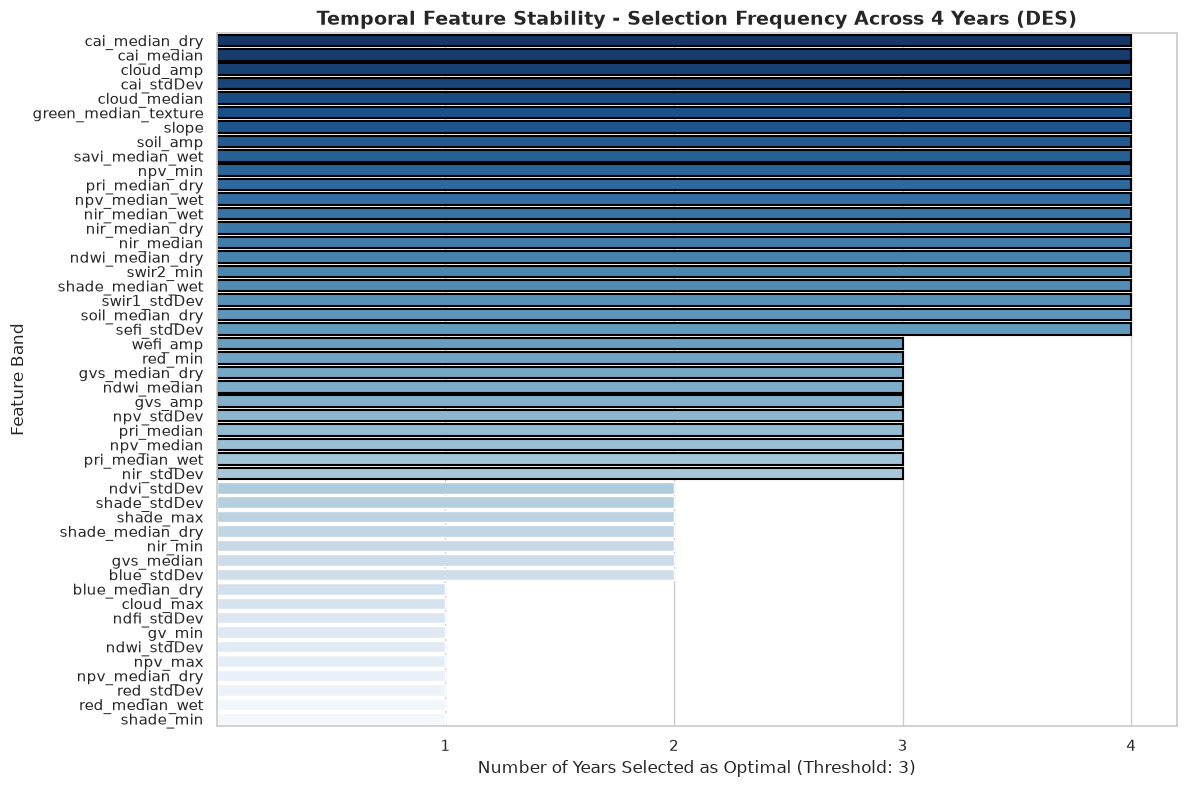

In [ ]:
# 3. Dynamic Plotting
plt.figure(figsize=(12, 8))
plot_data = master_rank_df[master_rank_df['years_selected'] > 0].sort_values(by='years_selected', ascending=False)

ax = sns.barplot(data=plot_data, x='years_selected', y='band', palette='Blues_r')
plt.title(f'Temporal Feature Stability - Selection Frequency Across {total_years_tested} Years ({region_id})', fontsize=14, fontweight='bold')
plt.xlabel(f'Number of Years Selected as Optimal (Threshold: {min_years_required})')
plt.ylabel('Feature Band')
plt.xticks(range(1, total_years_tested + 1)) # Dynamic X-axis

# Dynamically highlight features meeting the threshold
for p in ax.patches:
    if p.get_width() >= min_years_required:
        p.set_edgecolor('black')
        p.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [23]:
master_rank_df[master_rank_df['years_selected'] == 4].shape

(21, 6)

In [29]:
master_rank_df

,band,rank_1995,rank_2005,rank_2015,rank_2024,years_selected
0,blue_median_dry,NaN,NaN,NaN,1.0,1
1,blue_stdDev,1.0,1.0,NaN,NaN,2
2,cai_median,1.0,1.0,1.0,1.0,4
3,cai_median_dry,1.0,1.0,1.0,1.0,4
4,cai_stdDev,1.0,1.0,1.0,1.0,4
5,cloud_amp,1.0,1.0,1.0,1.0,4
6,cloud_max,NaN,NaN,NaN,1.0,1
7,cloud_median,1.0,1.0,1.0,1.0,4
8,green_median_texture,1.0,1.0,1.0,1.0,4
9,gv_min,1.0,6.0,NaN,NaN,1


In [30]:
master_rank_df.T.count(axis=1) 

band              48
rank_1995         40
rank_2005         35
rank_2015         33
rank_2024         37
years_selected    48
dtype: int64

In [37]:
X.shape

(6013, 119)

In [ ]:
# master_rank_df.to_csv('data/feature_importance_multiyear_region3_rfe.csv', index=False)